In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

# --- Load CSV ---
# Replace with your filename
file_path = "osc_peaks.csv"

df = pd.read_csv(file_path)

# --- Make each column into an array ---
time = df["Time(s)"].to_numpy()
ch1 = df["CH1(V)"].to_numpy()
ch2 = df["CH2(V)"].to_numpy()

# --- Find peaks in CH1(V) ---
# You can adjust "prominence" or "distance" if needed
peaks, properties = find_peaks(ch1, height=0)

print("peaks", peaks)

# Sort peaks by height and take the four tallest
peak_heights = ch1[peaks]
top4_idx = np.argsort(peak_heights)[-4:]   # indices into the peaks array
top4_peaks = peaks[top4_idx]

# Sort the 4 peaks by time order
top4_peaks = np.sort(top4_peaks)

# --- Measure time differences between the four tallest peaks ---
top4_times = time[top4_peaks]
time_differences = np.diff(top4_times)

print("Top 4 peak indices:", top4_peaks)
print("Top 4 peak times (s):", top4_times)
print("Time differences between consecutive top 4 peaks (s):", time_differences)

peaks [     2      5     10 ... 999986 999989 999992]
Top 4 peak indices: [116570 116572 116576 116578]
Top 4 peak times (s): [0.01185 0.01185 0.01185 0.01185]
Time differences between consecutive top 4 peaks (s): [0. 0. 0.]


In [10]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

# --- Load CSV ---
# Replace with your filename
file_path = "osc_peaks.csv"

df = pd.read_csv(file_path)

# --- Make each column into an array ---
time = df["Time(s)"].to_numpy()
ch1 = df["CH1(V)"].to_numpy()
ch2 = df["CH2(V)"].to_numpy()

# --- Find peaks in CH1(V) ---
# You can adjust "prominence" or "distance" if needed
peaks, properties = find_peaks(ch1)

# print("peaks", peaks)
# print(peaks.size)
# print(peaks.max())
print(ch1.size)
print(ch1.max())
print(ch1.argmax())
print(ch1.min())

# # Sort peaks by height and take the four tallest
# peak_heights = ch1[peaks]
# top4_idx = np.argsort(peak_heights)[-4:]   # indices into the peaks array
# top4_peaks = peaks[top4_idx]

# # Sort the 4 peaks by time order
# top4_peaks = np.sort(top4_peaks)

# # --- Measure time differences between the four tallest peaks ---
# top4_times = time[top4_peaks]
# time_differences = np.diff(top4_times)

# print("Top 4 peak indices:", top4_peaks)
# print("Top 4 peak times (s):", top4_times)
# print("Time differences between consecutive top 4 peaks (s):", time_differences)

1000000
0.313567
116570
-0.01383384


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ----------------------------------------------------------------------
# 1. Read the CSV file
# ----------------------------------------------------------------------
file_name = 'osc_peaks.csv'   # <-- CHANGE THIS TO YOUR FILE NAME

# Read with pandas (handles headers and scientific notation automatically)
df2 = pd.read_csv(file_name)

# Extract columns as numpy arrays
time2 = df2['Time(s)'].values        # 1D array of time stamps
ch12 = df2['CH1(V)'].values          # 1D array of channel 1 voltage
ch22 = df2['CH2(V)'].values          # 1D array of channel 2 voltage (optional)

print(f"Loaded {len(time2)} data points.")
print(f"Time range: {time2[0]:.6e} s to {time2[-1]:.6e} s")

Loaded 1000000 data points.
Time range: 1.080100e-02 s to 1.980100e-02 s


In [5]:
peaks, properties = find_peaks(ch12, height=0.1, distance=1)

# If you prefer to use prominence, you can add: prominence=0.1, etc.
# peaks, properties = find_peaks(ch1, prominence=0.1, distance=10)

if len(peaks) == 0:
    raise ValueError("No peaks found. Adjust the find_peaks parameters.")

print(f"Found {len(peaks)} peaks total.")

Found 129 peaks total.


Loaded 1000000 data points.
Time range: 1.080100e-02 s to 1.980100e-02 s
Found 29465 peaks total.

Four tallest peaks (sorted by time):
  Peak 1: Time = 1.185000e-02 s, Height = 0.313567 V
  Peak 2: Time = 1.185000e-02 s, Height = 0.311261 V
  Peak 3: Time = 1.185000e-02 s, Height = 0.306650 V
  Peak 4: Time = 1.185000e-02 s, Height = 0.292816 V

Time differences between consecutive tallest peaks (s):
  Δt1 = 0.000000e+00 s
  Δt2 = 0.000000e+00 s
  Δt3 = 0.000000e+00 s

Total time span from first to last tallest peak: 0.000000e+00 s


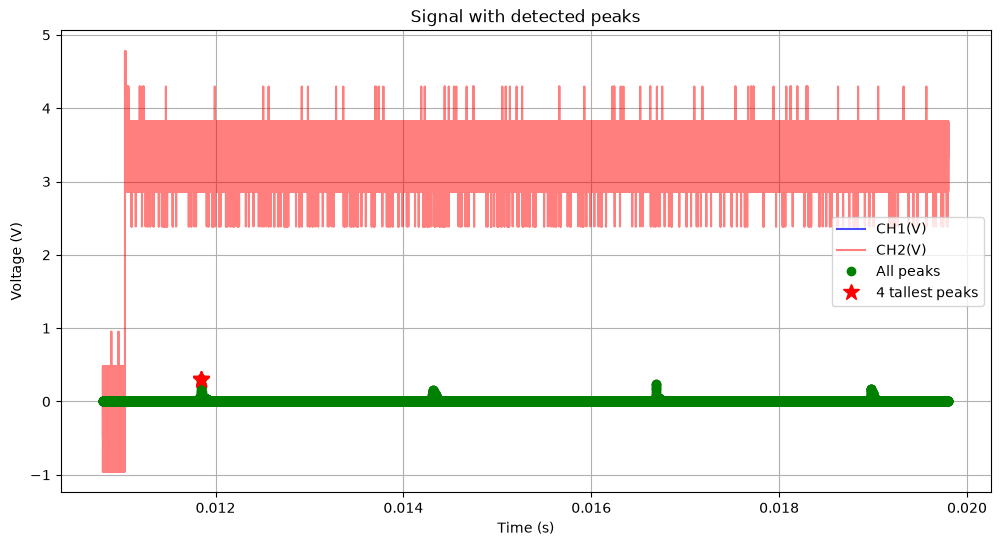

In [6]:
# -*- coding: utf-8 -*-
# Jupyter Notebook cell

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ----------------------------------------------------------------------
# 1. Read the CSV file
# ----------------------------------------------------------------------
file_name = 'osc_peaks.csv'   # <-- CHANGE THIS TO YOUR FILE NAME

# Read with pandas (handles headers and scientific notation automatically)
df = pd.read_csv(file_name)

# Extract columns as numpy arrays
time = df['Time(s)'].values        # 1D array of time stamps
ch1 = df['CH1(V)'].values          # 1D array of channel 1 voltage
ch2 = df['CH2(V)'].values          # 1D array of channel 2 voltage (optional)

print(f"Loaded {len(time)} data points.")
print(f"Time range: {time[0]:.6e} s to {time[-1]:.6e} s")

# ----------------------------------------------------------------------
# 2. Find peaks in CH1(V)
# ----------------------------------------------------------------------
# Adjust the parameters (height, distance, prominence) to suit your data.
# Here we use a simple approach: find all local maxima with a minimum
# vertical distance (height) and a minimum horizontal separation (distance).
# You may need to tune these values.

# Example: only peaks above 0.5 V (if your signal is positive) and at least
# 10 samples apart.
# Since we don't know your signal, we set loose thresholds – you can change them.
peaks, properties = find_peaks(ch1, height=0.0, distance=10)

# If you prefer to use prominence, you can add: prominence=0.1, etc.
# peaks, properties = find_peaks(ch1, prominence=0.1, distance=10)

if len(peaks) == 0:
    raise ValueError("No peaks found. Adjust the find_peaks parameters.")

print(f"Found {len(peaks)} peaks total.")

# ----------------------------------------------------------------------
# 3. Identify the four tallest peaks
# ----------------------------------------------------------------------
# Get peak heights (either from properties or directly from the signal)
peak_heights = ch1[peaks]   # or properties['peak_heights']

# Sort peaks by height descending and take the top 4
sorted_indices = np.argsort(peak_heights)[::-1]   # descending order
tallest_peak_positions = peaks[sorted_indices[:4]]   # indices of the 4 tallest peaks

# Get their corresponding times
tallest_times = time[tallest_peak_positions]
tallest_heights = ch1[tallest_peak_positions]

# Sort these four peaks by time (to compute consecutive differences)
sort_by_time = np.argsort(tallest_times)
tallest_times_sorted = tallest_times[sort_by_time]
tallest_heights_sorted = tallest_heights[sort_by_time]

# ----------------------------------------------------------------------
# 4. Compute time differences between consecutive tallest peaks
# ----------------------------------------------------------------------
time_diffs = np.diff(tallest_times_sorted)   # differences in seconds

# Print results
print("\nFour tallest peaks (sorted by time):")
for i, (t, h) in enumerate(zip(tallest_times_sorted, tallest_heights_sorted)):
    print(f"  Peak {i+1}: Time = {t:.6e} s, Height = {h:.6f} V")

print("\nTime differences between consecutive tallest peaks (s):")
for i, diff in enumerate(time_diffs):
    print(f"  Δt{i+1} = {diff:.6e} s")

# (Optional) Also print total span from first to last tallest peak
total_span = tallest_times_sorted[-1] - tallest_times_sorted[0]
print(f"\nTotal time span from first to last tallest peak: {total_span:.6e} s")

# ----------------------------------------------------------------------
# 5. (Optional) Visualise the data and mark the tallest peaks
# ----------------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(time, ch1, 'b-', label='CH1(V)', alpha=0.7)
plt.plot(time, ch2, 'r-', label='CH2(V)', alpha=0.5)   # if you want to see CH2

# Mark all peaks
plt.plot(time[peaks], ch1[peaks], 'go', label='All peaks')

# Mark the four tallest peaks with a different marker
plt.plot(tallest_times_sorted, tallest_heights_sorted, 'r*', 
         markersize=12, label='4 tallest peaks')

plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Signal with detected peaks')
plt.legend()
plt.grid(True)
plt.show()

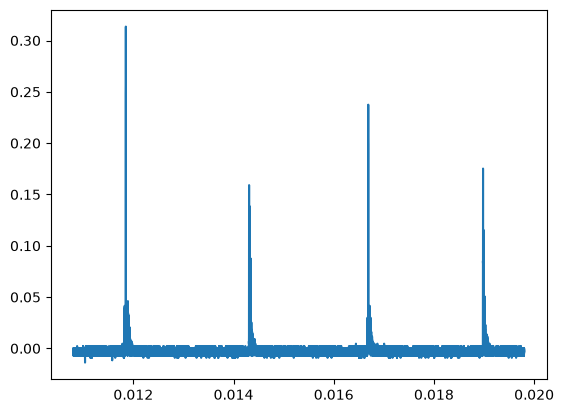

In [7]:
plt.plot(time, ch1)

In [ ]:
x = np.where( ch1 == 0.014)
print(x)
loc = ch1[500000]
print(loc)


(array([], dtype=int64),)
-0.00461128


In [14]:
print(ch1[113788
])

0.01383384


In [31]:
z = 0.0122
diffar = np.absolute(time-z)
index = diffar.argmin()
print("Nearest element to the given values is : ", ch1[index])
print("Index of nearest value is : ", index)

Nearest element to the given values is :  0.0
Index of nearest value is :  155398


[36347 38950 41573 43540 45595 47192]


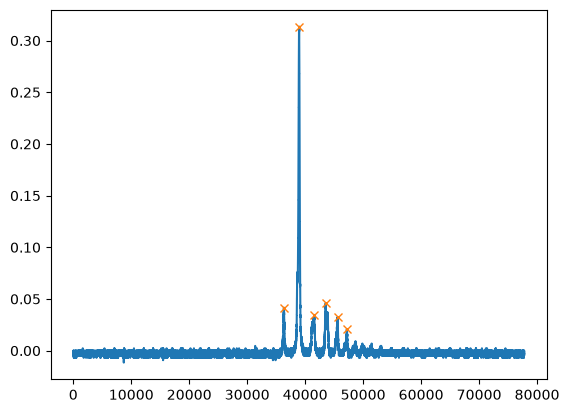

In [89]:
# range t = 0.013 and t =0.0115
first_p =ch1[77620:155398]
first_t = time[77620:155398]
single_peaks, _ = find_peaks(first_p, height = 0.01, width=10, distance=1000)
print(single_peaks)

plt.plot(first_p)
plt.plot(single_peaks, first_p[single_peaks], "x")

#plt.plot(first_t, first_p)

indices of max peaks [116581 389954 654253 908738]
heights of peaks [0.313567  0.1590891 0.2374809 0.1752286]
time values of peaks [0.01185  0.014311 0.016689 0.01898 ]


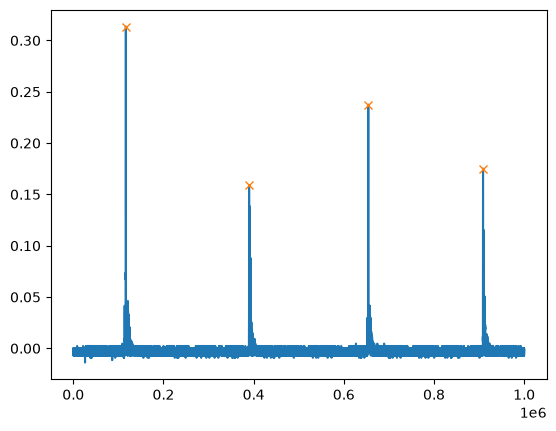

 distance between peak 1 and 3 0.0048389999999999996
 distance between peak 2 and 4 0.0046689999999999995


In [68]:
peaked, _ = find_peaks(ch1, height=0.02, width=10, distance=10000)

print("indices of max peaks", peaked)
print("heights of peaks", ch1[peaked])
print("time values of peaks", time[peaked])
#plt.plot(time, ch1)
plt.plot(ch1)
plt.plot(peaked, ch1[peaked], "x")
plt.show()


peak_heights = ch1[peaked]
peak_times = time[peaked]
d_p1_p3 = peak_times[2]- peak_times[0]
d_p2_p4 = peak_times[3]- peak_times[1]
print(" distance between peak 1 and 3", d_p1_p3)
print(" distance between peak 2 and 4", d_p2_p4)

 time scale in GHz/s 309.98140111593307


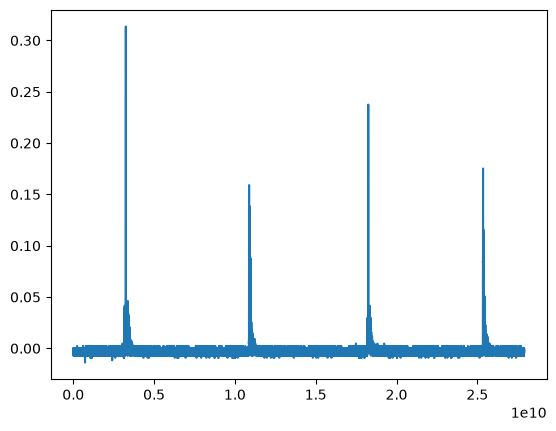

In [69]:
fsr = 1.5 #Ghz
dt1 = d_p1_p3
dt2 = d_p2_p4
tscale = fsr / dt1 #GHz/s
print(" time scale in GHz/s", tscale)
scan_rate = tscale*10e9 #Hz/s
t0 = time[0]
frequency = (time - t0) * scan_rate   
frequency_GHz = (time - t0) * tscale

plt.plot(frequency,ch1)





0.010801


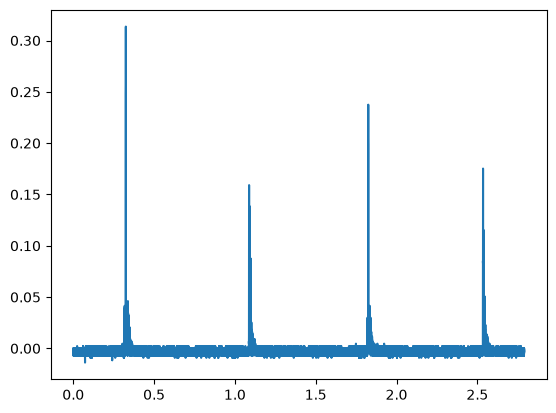

In [ ]:
plt.plot(frequency_GHz,ch1)
print(time[0])

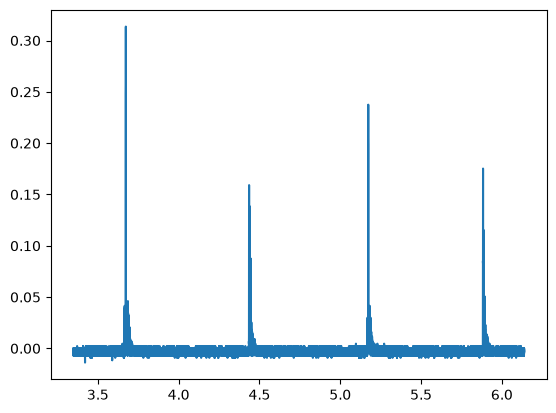

In [74]:
just_freq = time * tscale
plt.plot(just_freq,ch1)

In [62]:
print(time[peaked])

[0.01185  0.014311 0.016689 0.01898 ]


In [60]:
peakd_dex = find_peaks(ch1, height=0.02, width=10, distance=10000)
print(peakd_dex)

(array([116581, 389954, 654253, 908738]), {'peak_heights': array([0.313567 , 0.1590891, 0.2374809, 0.1752286]), 'prominences': array([0.32278956, 0.16831166, 0.24670346, 0.18445116]), 'left_bases': array([ 26124, 364482, 645641, 900963]), 'right_bases': array([155468, 423887, 699692, 965714]), 'widths': array([242.49999783, 243.75001952, 173.00002602, 223.00001301]), 'width_heights': array([0.15217222, 0.07493327, 0.11412917, 0.08300302]), 'left_ips': array([116446.49999349, 389817.74999349, 654172.49998699, 908617.99999566]), 'right_ips': array([116688.99999133, 390061.50001301, 654345.50001301, 908841.00000867])})


-0.00922256


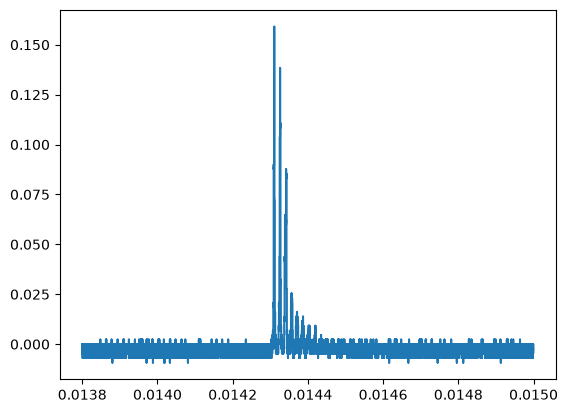

In [19]:
second_p = ch1[333176:466509]
second_t = time[333176:466509]
print(second_p.min())
plt.plot(second_t, second_p)

-0.00922256
[56783 58506 60315 61930 63515 65239]


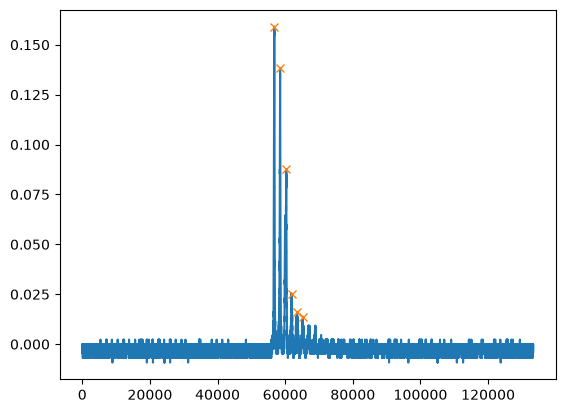

In [94]:
# range t = 0.013 and t =0.0115

second_p = ch1[333176:466509]
second_t = time[333176:466509]
print(second_p.min())
#plt.plot(second_t, second_p)

single_peaks2, _ = find_peaks(second_p, height = 0.01, width=10, distance=1000)
print(single_peaks2)

plt.plot(second_p)
plt.plot(single_peaks2, second_p[single_peaks2], "x")
